# Import libraries

In [130]:
import torch
import torch.nn as nn # Neutal network module
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation
import numpy as np

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Check GPU

In [131]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


# Download Datasets

In [132]:
# converts images into PyTorch tensors. For MNIST, Original image: 28 × 28 pixels becomes 1 × 28 × 28 Tensor
# The pixel values are also scaled from: 0–255 to 0.0–1.0
transform = transforms.ToTensor()
# Load the MNIST Dataset
train_dataset = datasets.MNIST(root = "../datasets/", train = True, download = True, transform=transform)
test_dataset = datasets.MNIST(root="../datasets/", train = False, download = True, transform=transform)

In [133]:
print("Number of training samples: " + str(len(train_dataset)) + "\n" +
      "Number of testing samples: " + str(len(test_dataset)))
print("Datatype of the 1st training sample: ", train_dataset[0][0].type())
print("Size of the 1st training sample: ", train_dataset[0][0].size())

Number of training samples: 60000
Number of testing samples: 10000
Datatype of the 1st training sample:  torch.FloatTensor
Size of the 1st training sample:  torch.Size([1, 28, 28])


# Create dataloaders

In [134]:
# data is loaded into a DataLoader with batch size at 64
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Explore Dataset

In [135]:
image, label = next(iter(train_loader))

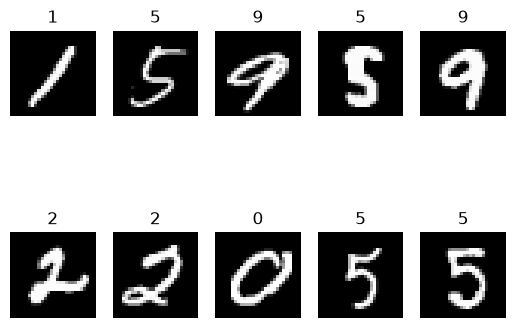

In [136]:
fig, axes = plt.subplots(2,5)
for i, ax in enumerate(axes.flat):
    ax.imshow(image[i].squeeze(), cmap = "gray")
    ax.set_title(label[i].item())
    ax.axis("off")

# Logistic Regression

Logistic regression is a supervised machine learning algorithm used for classification, predicting the probability of an event (e.g., yes/no) rather than continuous numbers. It models data using an S-shaped sigmoid function, mapping inputs to probabilities between 0 and 1.

In [137]:
# This model will take a 28 ×28-pixel image of handwritten digits as input 
# and classify them into one of the 10 output classes of digits 0 to 9.
class LogisticRegression (nn.Module):
    def __init__(self, n_inputs, n_outputs):
        # super().__init__(): Triggers the constructor of the parent class (nn.Module).
        # It sets up internal PyTorch registries necessary for tracking weights, biases, and submodules.
        super().__init__()
        #self.linear = nn.Linear(...): Registers a fully connected (dense) layer as an attribute of the class.
        # 28*28: Sets the input feature size to 784, matching the total pixels of a flattened 28 × 28 
        # 10: Sets the output size to 10, creating one raw score (logit) for each potential target class.
        self.linear = nn.Linear(n_inputs, n_outputs) 

    def forward(self,x):
        # The sigmoid function is an activation function that converts any real number into a value between 0 and 1.
        # self.linear(x) computes the raw score (logit).
        # torch.sigmoid(...) converts that score into a value between 0 and 1.
        # y_pred becomes a probability-like output that is well suited for binary classification.
        y_predict = torch.sigmoid(self.linear(x))
        return y_predict

In [138]:
# instantiate the model
n_inputs = 28*28 # makes a 1D vector of 784
n_outputs = 10
log_regr = LogisticRegression(n_inputs, n_outputs)

In [139]:
# defining the optimizer
# Uses Stochastic Gradient Descent (SGD).
# The learning rate (lr=0.001) controls how much the weights are updated during each optimization step.
optimizer = torch.optim.SGD(log_regr.parameters(), lr=0.001)
# defining Cross-Entropy loss
# This computes the difference between the predicted logits and the true class labels for multiclass classification.
criterion = torch.nn.CrossEntropyLoss()

In [140]:
epochs = 50
loss_total = []
accuracy_total = []
# Training loop
# Each batch contains 64 images and 64 labels
for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Prevents gradients from accumulating across batches.
        optimizer.zero_grad()
        # image.view(-1, 28*28) means flatten images. Changes the shape from 64×1×28×28 to 64×784 because a linear layer expects vectors as input.
    
        # Forward Pass 
        # Produces a prediction for each image in the batch.
        outputs = log_regr(images.view(-1, 28*28))

        # Compute Loss
        # Measures how far the predictions are from the true labels.
        loss = criterion(outputs, labels)

        # Backpropagation
        # Computes the gradients of the loss with respect to all trainable parameters.
        loss.backward()

        # Update Parameters
        # Uses the computed gradients to update the weights and biases.
        optimizer.step()
        
    loss_total.append(loss.item())
    correct = 0
    for images, labels in test_loader:
        outputs = log_regr(images.view(-1, 28*28))
        # Predict the Class
        # Suppose the model outputs [0.2, 1.5, -0.3, ..., 2.7] The largest value is at index 9, so the predicted digit is 9.
        _, predicted = torch.max(outputs.data,1)
        #print(predicted)
        # Count Correct Predictions
        # Adds the number of correct predictions in the current batch.
        correct += (predicted == labels).sum()
    # If the model correctly classifies 9,200 out of 10,000 test images, Accuracy = 92%
    accuracy = 100 * (correct.item())/len(test_dataset)
    accuracy_total.append(accuracy)
    print('Epoch: {}. Loss: {}. Accuracy: {}'.format(epoch, loss.item(), accuracy))


Epoch: 0. Loss: 2.2327463626861572. Accuracy: 49.63
Epoch: 1. Loss: 2.183638572692871. Accuracy: 64.08
Epoch: 2. Loss: 2.1440510749816895. Accuracy: 70.58
Epoch: 3. Loss: 2.1117420196533203. Accuracy: 73.72
Epoch: 4. Loss: 2.049990653991699. Accuracy: 75.46
Epoch: 5. Loss: 2.029510021209717. Accuracy: 77.03
Epoch: 6. Loss: 2.0724289417266846. Accuracy: 78.4
Epoch: 7. Loss: 2.0016772747039795. Accuracy: 79.5
Epoch: 8. Loss: 1.9962362051010132. Accuracy: 80.15
Epoch: 9. Loss: 1.9442026615142822. Accuracy: 80.62
Epoch: 10. Loss: 2.0034279823303223. Accuracy: 81.09
Epoch: 11. Loss: 1.9125511646270752. Accuracy: 81.35
Epoch: 12. Loss: 1.930080771446228. Accuracy: 81.6
Epoch: 13. Loss: 1.8932909965515137. Accuracy: 81.84
Epoch: 14. Loss: 1.8901562690734863. Accuracy: 82.06
Epoch: 15. Loss: 1.8466507196426392. Accuracy: 82.31
Epoch: 16. Loss: 1.8799189329147339. Accuracy: 82.45
Epoch: 17. Loss: 1.8547720909118652. Accuracy: 82.59
Epoch: 18. Loss: 1.8244924545288086. Accuracy: 82.79
Epoch: 19.

# Loss plot

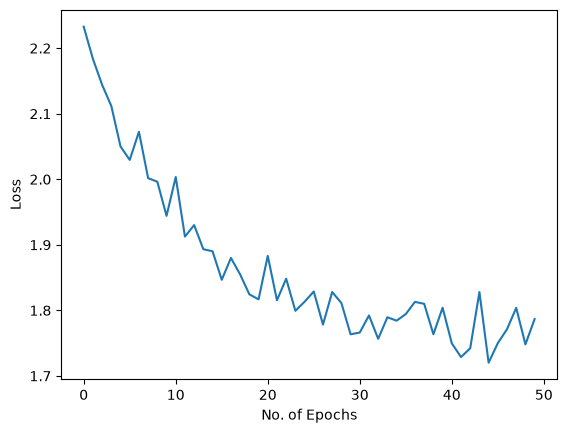

In [141]:
plt.plot(loss_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# Accuracy plot

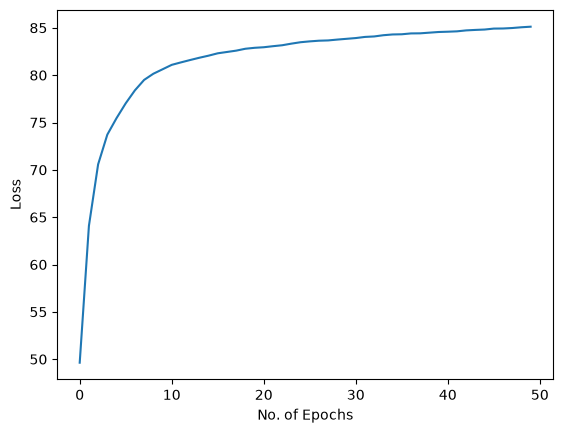

In [142]:
plt.plot(accuracy_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# Multi-Layer Perceptron (MLP) neural network

In [170]:
class MultilayerPerceptron (nn.Module):
    def __init__ (self):
        super(MultilayerPerceptron, self).__init__()

        self.network = nn.Sequential(
            # A fully connected layer that takes the 784 input features and projects them to 256 hidden features.
            # Input layer to hidden layer
            nn.Linear(784,128), 
            # Introduces non-linearity, allowing the network to learn complex patterns instead of just linear equations.
            nn.ReLU(),
            # Compresses the 256 features down to a tighter representation of 128 features.
            # Hidden layer 2
            #nn.Linear(256, 128),
            #nn.ReLU(),
            # Outputs 10 raw scores (logits). Each score corresponds to one of the 10 possible classes.
            # Hiden layer to output layer
            nn.Linear(128, 10)
        )

    def forward (self, x):
        return self.network(x)

In [172]:
# instantiate the model
MLP_model = MultilayerPerceptron()
print(MLP_model)

MultilayerPerceptron(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [173]:
optimizer = torch.optim.Adam(MLP_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [174]:
epochs = 15
loss_total = []
accuracy_total = []
# Training loop
# Each batch contains 64 images and 64 labels
for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Prevents gradients from accumulating across batches.
        optimizer.zero_grad()
        # image.view(-1, 28*28) means flatten images. Changes the shape from 64×1×28×28 to 64×784 because a linear layer expects vectors as input.
    
        # Forward Pass 
        # Produces a prediction for each image in the batch.
        outputs = MLP_model(images.view(-1, 28*28))

        # Compute Loss
        # Measures how far the predictions are from the true labels.
        loss = criterion(outputs, labels)

        # Backpropagation
        # Computes the gradients of the loss with respect to all trainable parameters.
        loss.backward()

        # Update Parameters
        # Uses the computed gradients to update the weights and biases.
        optimizer.step()
        
    loss_total.append(loss.item())
    correct = 0
    for images, labels in test_loader:
        outputs = MLP_model(images.view(-1, 28*28))
        # Predict the Class
        # Suppose the model outputs [0.2, 1.5, -0.3, ..., 2.7] The largest value is at index 9, so the predicted digit is 9.
        _, predicted = torch.max(outputs.data,1)
        #print(predicted)
        # Count Correct Predictions
        # Adds the number of correct predictions in the current batch.
        correct += (predicted == labels).sum()
    # If the model correctly classifies 9,200 out of 10,000 test images, Accuracy = 92%
    accuracy = 100 * (correct.item())/len(test_dataset)
    accuracy_total.append(accuracy)
    print('Epoch: {}. Loss: {}. Accuracy: {}'.format(epoch, loss.item(), accuracy))


Epoch: 0. Loss: 0.24293363094329834. Accuracy: 94.58
Epoch: 1. Loss: 0.07388584315776825. Accuracy: 96.18
Epoch: 2. Loss: 0.02871263213455677. Accuracy: 96.73
Epoch: 3. Loss: 0.05457843840122223. Accuracy: 96.89
Epoch: 4. Loss: 0.08225089311599731. Accuracy: 97.58
Epoch: 5. Loss: 0.047810181975364685. Accuracy: 97.49
Epoch: 6. Loss: 0.011145630851387978. Accuracy: 97.72
Epoch: 7. Loss: 0.03610946610569954. Accuracy: 97.69
Epoch: 8. Loss: 0.007496544625610113. Accuracy: 97.76
Epoch: 9. Loss: 0.02996583841741085. Accuracy: 97.71
Epoch: 10. Loss: 0.03644455596804619. Accuracy: 97.75
Epoch: 11. Loss: 0.002069842768833041. Accuracy: 97.7
Epoch: 12. Loss: 0.11540815979242325. Accuracy: 97.96
Epoch: 13. Loss: 0.008843264542520046. Accuracy: 97.76
Epoch: 14. Loss: 0.0005433625774458051. Accuracy: 97.97


# Loss plot

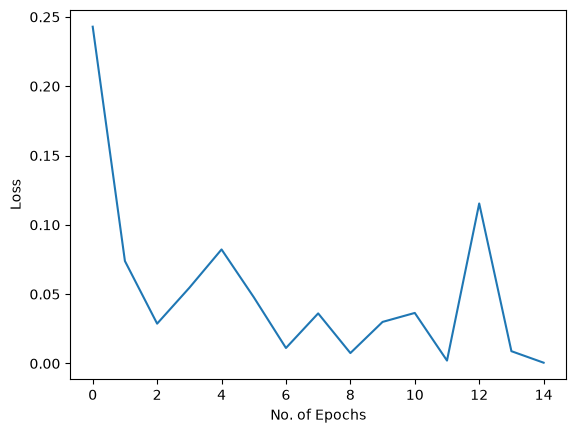

In [175]:
plt.plot(loss_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# Accuracy plot

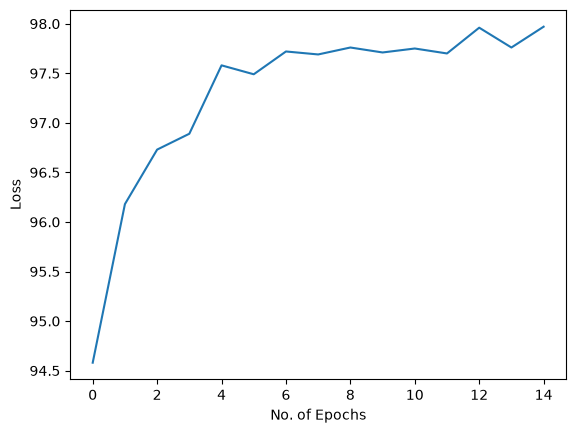

In [176]:
plt.plot(accuracy_total)
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.show()

# CNN

In [ ]:
class CNN (nn.Module):
    